<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_18_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv("/content/teslimat_noktalari.csv")

In [8]:
df.head()

,siparis_id,x_km,y_km
0,S50001,13.993,1.257
1,S50002,-1.962,1.116
2,S50003,0.829,4.456
3,S50004,5.215,-0.484
4,S50005,14.401,2.183


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   siparis_id  495 non-null    object 
 1   x_km        495 non-null    float64
 2   y_km        495 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.7+ KB


In [12]:
df.describe()

,x_km,y_km
count,495.000000,495.000000
mean,6.041129,2.083065
std,5.699809,1.666925
min,-2.462000,-3.810000
25%,1.533500,0.954500
50%,4.216000,2.254000
75%,13.328500,3.125000
max,15.491000,7.986000


Text(0.5, 1.0, 'Teslimat Noktaları')

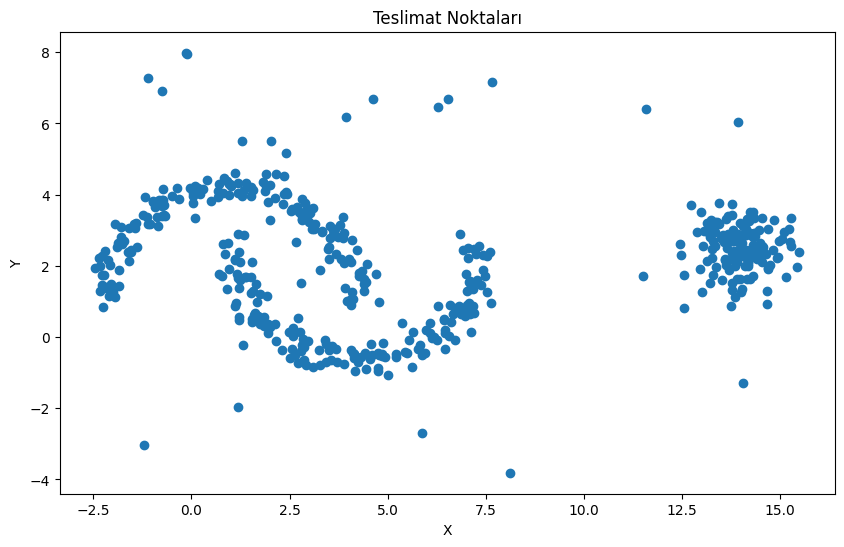

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x_km'], df['y_km'])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Teslimat Noktaları')

In [16]:
#Ölçeklendirme normalde yapılabilir. benzer datalar olduğu 2 sütun var bir biri ile benzer. o yüzden yapmayacağız.

X = df[['x_km', 'y_km']]

In [18]:
#K-means uygulama.

kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_kume'] = kmeans.fit_predict(X)
#

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

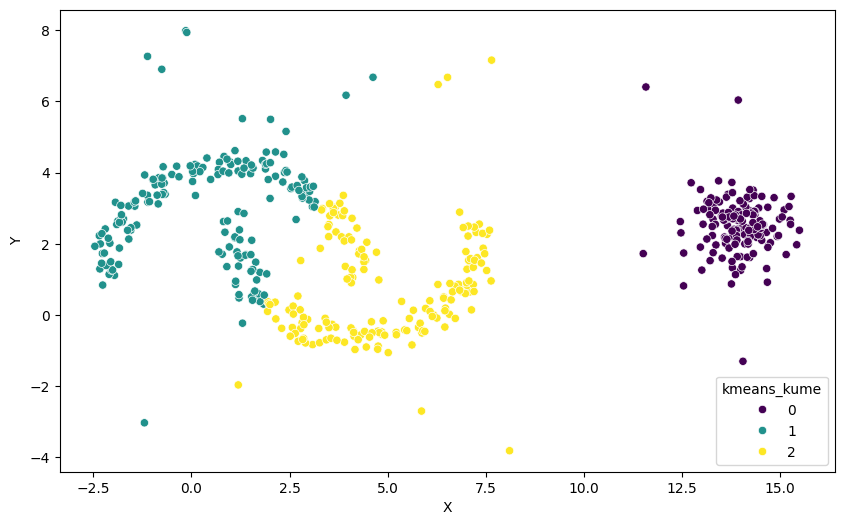

In [20]:
#K-means Görselleştirme

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_km', y='y_km', hue='kmeans_kume', data=df, palette='viridis')
plt.xlabel('X')
plt.ylabel('Y')
plt

In [21]:
# K means kavisler ortadan bölmüş, 2. olarak gürüldü olarak görebileceğimiz dataları da dahil etmiş.

In [26]:
#DBSCAN UYGULAMA #min_samples= 5 vererek ilerlenebilir. genel tutum sütun sayıs + 2 dir. eps değeri for döngüsü ile 0.3,0.4,0.5 .... 1.0 a kadar bakılabilir.

eps_listesi = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for eps in eps_listesi:
  model = DBSCAN(eps=eps, min_samples=5)
  etiketler = model.fit_predict(X)
  kume_sayisi = etiketler.max() + 1
  gurultu_sayisi = (etiketler == -1).sum()
  print(f"Eps: {eps}, Küme Sayısı: {kume_sayisi}, Gürültü Sayısı: {gurultu_sayisi}")

#



#

Eps: 0.3, Küme Sayısı: 24, Gürültü Sayısı: 84
Eps: 0.4, Küme Sayısı: 5, Gürültü Sayısı: 44
Eps: 0.5, Küme Sayısı: 3, Gürültü Sayısı: 31
Eps: 0.6, Küme Sayısı: 3, Gürültü Sayısı: 24
Eps: 0.7, Küme Sayısı: 3, Gürültü Sayısı: 19
Eps: 0.8, Küme Sayısı: 2, Gürültü Sayısı: 18
Eps: 0.9, Küme Sayısı: 2, Gürültü Sayısı: 18
Eps: 1.0, Küme Sayısı: 2, Gürültü Sayısı: 17


In [25]:
# Başarı kriterlerinde önemli konular: Ne kadar az gürültü değeri varsa o kadar iyi. Gürültü değerine küme olarak -1 değeri veriyor. Ben denediğim eps değerinde 0.6 yı seçebilirim. veya 0.5 i.

In [28]:
#Final Model

final_model = DBSCAN(eps=0.6, min_samples=5)
df['kume'] = final_model.fit_predict(X)
#
print(df['kume'].value_counts())
#-1 değeri gürültü değerleri. Kümelerin içene alınmayanlar. Kümeler 0 ile başlıyor.

kume
 1    164
 2    164
 0    143
-1     24
Name: count, dtype: int64


In [31]:
#Başarı Metrikleri

kume_sayisi = df["kume"].max() + 1
gurultu_sayisi = (df["kume"] == -1).sum()
gurult_orani = gurultu_sayisi / len(df) * 100
print(f"Küme Sayısı: {kume_sayisi}")
print(f"Gürültü Oranı: {gurult_orani:.2f}%")
print(f"Gürültü Sayısı: {gurultu_sayisi}")
#
#

Küme Sayısı: 3
Gürültü Oranı: 4.85%
Gürültü Sayısı: 24


Text(0.5, 1.0, 'DBSCAN Kümelerile Görselleştirilmiş Teslimat Noktaları')

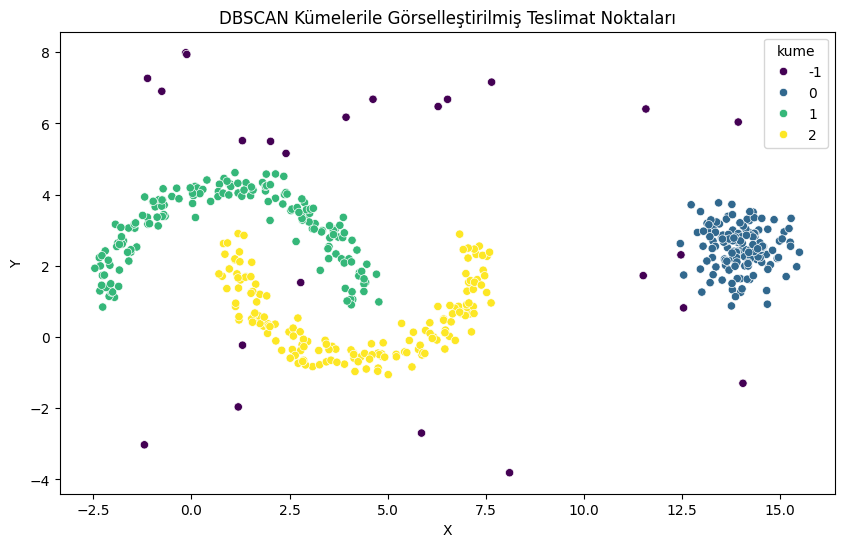

In [33]:
#Kümeleri Görselleştirme

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_km', y='y_km', hue='kume', data=df, palette='viridis')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('DBSCAN Kümelerile Görselleştirilmiş Teslimat Noktaları')
#

In [ ]:
# K-means kavisli şeritlerde data setlerinde istenilen performansı veremeyebilir. Kavisli ve düzensiz şekilli datasetlerinde DBscan daha rahat sonuçlar verir.